# 04 - Train Linear Regression

Using `pd.read_pickle()` for loading engineered datasets.

## 1. Import Libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load Dataset

In [17]:
import joblib

X_train = joblib.load('data/ready_for_train/X_train_final.pkl')
X_test = joblib.load('data/ready_for_train/X_test_final.pkl')

y_train = joblib.load('data/ready_for_train/y_train_log.pkl')
y_test = joblib.load('data/ready_for_train/y_test_log.pkl')

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (79448, 31)
X_test : (19862, 31)
y_train: (79448,)
y_test : (19862,)


## 3. Feature Engineering Summary

In [3]:
X_train[:5]

array([[ 0.05016324,  1.36855612, -0.98775603,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ],
       [ 1.30059999,  0.24823581, -0.98775603,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.84589572, -0.31192434,  0.58388622,  1.        ,  0.        ,
       

In [4]:
print(type(X_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'pandas.Series'>


In [5]:
print('Number of features:', X_train.shape[1])
print('Shape:', X_train.shape)

Number of features: 31
Shape: (79448, 31)


## 4. Linear Regression - Scikit Learn

In [35]:
# ============================================================
# MODEL 1: Train trên log1p(price)
# ============================================================

lr_log = LinearRegression()
lr_log.fit(X_train, y_train)

y_pred_log = lr_log.predict(X_test)

# Đánh giá trên log-space
r2_log = r2_score(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)

# Chuyển về scale gốc
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# Đánh giá trên original-space
r2_original = r2_score(y_test_original, y_pred_original)
mae_original = mean_absolute_error(y_test_original, y_pred_original)
mse_original = mean_squared_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mse_original)

print("=" * 50)
print("Training Linear Regression với price đã được Log-Transformation")
print("=" * 50)

print("\n[Đánh giá trên không gian Log]")
print(f"MAE  : {mae_log:.4f}")
print(f"MSE  : {mse_log:.4f}")
print(f"RMSE : {rmse_log:.4f}")
print(f"R2   : {r2_log:.4f}")

print("\n[Đánh giá dựa trên giá gốc]")
print(f"MAE  : {mae_original:.4f}")
print(f"MSE  : {mse_original:.4f}")
print(f"RMSE : {rmse_original:.4f}")
print(f"R2   : {r2_original:.4f}")

# ============================================================
# MODEL 2: Train trực tiếp trên price gốc
# ============================================================

lr_original = LinearRegression()
lr_original.fit(X_train, np.expm1(y_train))

y_pred_original_direct = lr_original.predict(X_test)

r2_direct = r2_score(y_test_original, y_pred_original_direct)
mae_direct = mean_absolute_error(y_test_original, y_pred_original_direct)
mse_direct = mean_squared_error(y_test_original, y_pred_original_direct)
rmse_direct = np.sqrt(mse_direct)

print("\n" + "=" * 50)
print("Linear Regression được train trên giá gốc")
print("=" * 50)

print(f"MAE  : {mae_direct:.4f}")
print(f"MSE  : {mse_direct:.4f}")
print(f"RMSE : {rmse_direct:.4f}")
print(f"R2   : {r2_direct:.4f}")

Training Linear Regression với price đã được Log-Transformation

[Đánh giá trên không gian Log]
MAE  : 0.9634
MSE  : 1.2544
RMSE : 1.1200
R2   : 0.6958

[Đánh giá dựa trên giá gốc]
MAE  : 1746.8648
MSE  : 11540643.1895
RMSE : 3397.1522
R2   : 0.3628

Linear Regression được train trên giá gốc
MAE  : 1733.5266
MSE  : 9289463.0924
RMSE : 3047.8621
R2   : 0.4871


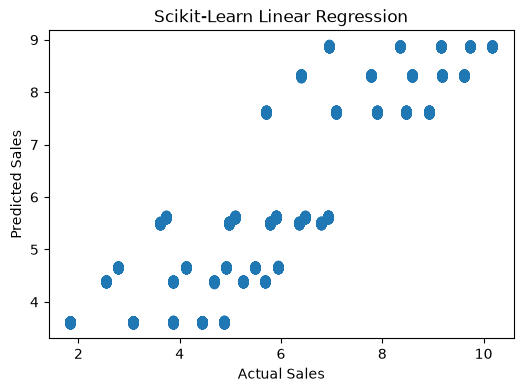

In [7]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_sklearn)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Scikit-Learn Linear Regression')
plt.show()


## 5. Linear Regression From Scratch

In [41]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.loss_history = []

    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):

            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            self.loss_history.append(
                np.mean((y - y_pred) ** 2)
            )

    def predict(self, X):
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias


In [ ]:
# ============================================================
# MODEL 1: Train trên log1p(price)
# ============================================================

lr_log_scratch = LinearRegressionScratch()
lr_log_scratch.fit(X_train, y_train)

y_pred_log = lr_log_scratch.predict(X_test)

# Đánh giá trên log-space
r2_log = r2_score(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)

# Chuyển về scale gốc
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# Đánh giá trên original-space
r2_original = r2_score(y_test_original, y_pred_original)
mae_original = mean_absolute_error(y_test_original, y_pred_original)
mse_original = mean_squared_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mse_original)

print("=" * 50)
print("Training Linear Regression với price đã được Log-Transformation")
print("=" * 50)

print("\n[Đánh giá trên không gian Log]")
print(f"MAE  : {mae_log:.4f}")
print(f"MSE  : {mse_log:.4f}")
print(f"RMSE : {rmse_log:.4f}")
print(f"R2   : {r2_log:.4f}")

print("\n[Đánh giá dựa trên giá gốc]")
print(f"MAE  : {mae_original:.4f}")
print(f"MSE  : {mse_original:.4f}")
print(f"RMSE : {rmse_original:.4f}")
print(f"R2   : {r2_original:.4f}")

# ============================================================
# MODEL 2: Train trực tiếp trên price gốc
# ============================================================

lr_original_scratch = LinearRegressionScratch()
lr_original_scratch.fit(X_train, np.expm1(y_train))

y_pred_original_direct = lr_original_scratch.predict(X_test)

r2_direct = r2_score(y_test_original, y_pred_original_direct)
mae_direct = mean_absolute_error(y_test_original, y_pred_original_direct)
mse_direct = mean_squared_error(y_test_original, y_pred_original_direct)
rmse_direct = np.sqrt(mse_direct)

print("\n" + "=" * 50)
print("Linear Regression được train trên giá gốc")
print("=" * 50)

print(f"MAE  : {mae_direct:.4f}")
print(f"MSE  : {mse_direct:.4f}")
print(f"RMSE : {rmse_direct:.4f}")
print(f"R2   : {r2_direct:.4f}")

Training Linear Regression với price đã được Log-Transformation

[Đánh giá trên không gian Log]
MAE  : 1.0446
MSE  : 1.6302
RMSE : 1.2768
R2   : 0.6046

[Đánh giá dựa trên giá gốc]
MAE  : 1954.6288
MSE  : 18070478.7930
RMSE : 4250.9386
R2   : 0.0022

Linear Regression được train trên giá gốc
MAE  : 2044.6307
MSE  : 11485073.1513
RMSE : 3388.9634
R2   : 0.3658


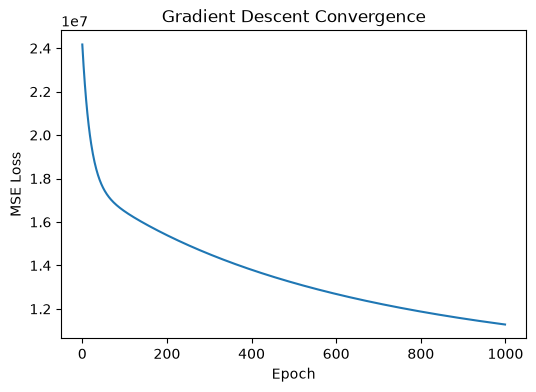

In [26]:
plt.figure(figsize=(6,4))
plt.plot(lr_original_scratch.loss_history)
plt.title('Gradient Descent Convergence')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()


## 6. Ridge Regression with Hyperparameter Tuning and Cross Validation

In [42]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_train_original = np.expm1(y_train)
y_test_original = np.expm1(y_test)

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train, y_train_original)

best_ridge = ridge_grid.best_estimator_
ridge_pred = best_ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test_original, ridge_pred)
ridge_mse = mean_squared_error(y_test_original, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test_original, ridge_pred)

cv_scores = cross_val_score(
    best_ridge,
    X_train,
    y_train_original,
    cv=5,
    scoring="r2"
)

print("Best Alpha:", ridge_grid.best_params_)
print("CV Mean R2:", cv_scores.mean())
print("Test MAE:", ridge_mae)
print("Test MSE:", ridge_mse)
print("Test RMSE:", ridge_rmse)
print("Test R2:", ridge_r2)

Best Alpha: {'alpha': 1}
CV Mean R2: 0.4823335393427449
Test MAE: 1733.5155486029364
Test MSE: 9289492.164317928
Test RMSE: 3047.8668219457895
Test R2: 0.48706649822657877


## 6. Model Comparison

In [ ]:
# Metrics dùng cho MODEL COMPARISON (Build From Scratch)


y_train_original = np.expm1(y_train)
y_test_original = np.expm1(y_test)

start_time = time.time()
lr_model.fit(X_train, y_train_original)
train_time_sklearn = time.time() - start_time

y_pred_sklearn = lr_model.predict(X_test)

mae_sklearn = mean_absolute_error(y_test_original, y_pred_sklearn)
mse_sklearn = mean_squared_error(y_test_original, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_test_original, y_pred_sklearn)

start_time = time.time()
lr_original_scratch = LinearRegressionScratch()
lr_original_scratch.fit(X_train, np.expm1(y_train))
train_time_scratch = time.time() - start_time

y_pred_scratch = lr_original_scratch.predict(X_test)

mae_scratch = mean_absolute_error(y_test_original, y_pred_scratch)
mse_scratch = mean_squared_error(y_test_original, y_pred_scratch)
rmse_scratch = np.sqrt(mse_scratch)
r2_scratch = r2_score(y_test_original, y_pred_scratch)

linear_regression_scratch_results = {
    'Model': 'Linear Regression (Scratch)',
    'MAE': mae_scratch,
    'MSE': mse_scratch,
    'RMSE': rmse_scratch,
    'R2': r2_scratch,
    'Training_Time': train_time_scratch
}

comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score', 'Training Time (s)'],
    'Scikit-Learn': [mae_sklearn, mse_sklearn, rmse_sklearn, r2_sklearn, train_time_sklearn],
    'From Scratch': [mae_scratch, mse_scratch, rmse_scratch, r2_scratch, train_time_scratch]
})

comparison

,Metric,Scikit-Learn,From Scratch
0,MAE,1.733527e+03,2.044631e+03
1,MSE,9.289463e+06,1.148507e+07
2,RMSE,3.047862e+03,3.388963e+03
3,R2 Score,4.870681e-01,3.658341e-01
4,Training Time (s),3.247523e-02,3.162133e+00


In [38]:
# Save Scratch Model
import os
import joblib

MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(
    lr_model,
    os.path.join(MODEL_DIR, 'model_linear_regression_scratch.pkl')
)

print(
    f'Mô hình Linear Regression Scratch đã được lưu tại '
    f'{os.path.join(MODEL_DIR, "model_linear_regression_scratch.pkl")}'
)


Mô hình Linear Regression Scratch đã được lưu tại ./models/model_linear_regression_scratch.pkl


## 7. Final Conclusion

- Linear Regression From Scratch was implemented to understand Gradient Descent and parameter optimization.
- Scikit-Learn Linear Regression provides a faster and more reliable implementation for practical applications.
- Ridge Regression was introduced to perform hyperparameter tuning and create a fair comparison with other tuned models in the project.
- 5-Fold Cross Validation was used to evaluate model stability and generalization ability.
- In production environments, optimized library implementations should be preferred over educational scratch implementations.
